# Лабораторная работа 1. ResNet-18 + AdamW на Fashion MNIST

## 1. Импорты


In [26]:
%matplotlib inline

import os
import random
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset


## 2. Гиперпараметры


In [27]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 28
FASHION_MEAN = 0.2860
FASHION_STD = 0.3530

BATCH_SIZE = 96
NUM_EPOCHS = 12
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
ADAM_BETAS = (0.9, 0.999)
ETA_MIN = 1e-6
VAL_SIZE = 0.1
SEED = 42
NUM_WORKERS = 0
CPU_THREADS = min(8, os.cpu_count() or 8)
USE_FOCAL_LOSS = False


## 3. Устройство, seed и фабрики оптимизатора


In [28]:
def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    try:
        candidates.insert(0, Path(__file__).resolve().parents[1])
    except NameError:
        pass

    for candidate in candidates:
        if (candidate / "data" / "fashion-mnist_train.csv").exists():
            return candidate

    raise FileNotFoundError(
        "Не найден каталог data с файлами fashion-mnist_train.csv / fashion-mnist_test.csv"
    )


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def configure_runtime() -> torch.device:
    device = get_device()
    if device.type == "cpu":
        torch.set_num_threads(CPU_THREADS)
        torch.set_num_interop_threads(1)
    return device


def initialize_weights(module: nn.Module) -> None:
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.constant_(module.weight, 1)
        nn.init.constant_(module.bias, 0)
    elif isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, 0, 0.01)
        nn.init.constant_(module.bias, 0)


## 4. Модель ResNet-18

In [29]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


In [30]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, in_channels=1):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        self.apply(initialize_weights)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = [ResidualBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = torch.flatten(self.avgpool(x), 1)
        return self.fc(x)


with torch.no_grad():
    _check = ResNet18()(torch.randn(2, 1, 28, 28))
print("Проверка forward:", tuple(_check.shape))


Проверка forward: (2, 10)


## 5. Данные Fashion MNIST


In [31]:
def get_train_transforms():
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.Affine(translate_percent=0.08, scale=(0.9, 1.1), rotate=(-12, 12), p=0.5),
            A.CoarseDropout(
                num_holes_range=(1, 2),
                hole_height_range=(4, 8),
                hole_width_range=(4, 8),
                p=0.3,
            ),
            A.Normalize(mean=FASHION_MEAN, std=FASHION_STD),
            ToTensorV2(),
        ]
    )


def get_eval_transforms():
    return A.Compose(
        [
            A.Normalize(mean=FASHION_MEAN, std=FASHION_STD),
            ToTensorV2(),
        ]
    )


In [32]:
class FashionMNISTDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        self.features = np.asarray(features, dtype=np.uint8).reshape(-1, IMAGE_SIZE, IMAGE_SIZE)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        image = self.features[index]
        label = self.labels[index]
        if self.transform is not None:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        return image, label


def load_csv_xy(csv_path: Path):
    df = pd.read_csv(csv_path)
    return df.iloc[:, 1:].to_numpy(), df.iloc[:, 0].to_numpy()


def create_dataloaders(data_dir: Path, batch_size=BATCH_SIZE, val_size=VAL_SIZE, num_workers=NUM_WORKERS):
    train_features, train_labels = load_csv_xy(data_dir / "fashion-mnist_train.csv")
    test_features, test_labels = load_csv_xy(data_dir / "fashion-mnist_test.csv")
    x_train, x_val, y_train, y_val = train_test_split(
        train_features, train_labels, test_size=val_size, random_state=SEED, stratify=train_labels
    )

    train_dataset = FashionMNISTDataset(x_train, y_train, transform=get_train_transforms())
    val_dataset = FashionMNISTDataset(x_val, y_val, transform=get_eval_transforms())
    test_dataset = FashionMNISTDataset(test_features, test_labels, transform=get_eval_transforms())

    pin_memory = torch.cuda.is_available()
    common = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=pin_memory)
    train_loader = DataLoader(train_dataset, shuffle=True, **common)
    val_loader = DataLoader(val_dataset, shuffle=False, **common)
    test_loader = DataLoader(test_dataset, shuffle=False, **common)
    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset


Device: cpu
CPU threads: 8
Data dir: /home/asgaroth/University/4 курс/ОИвИС/IP_AI_26/reports/Kavalchuk Artyom/Lab 1/data
Train: (60000, 784) Test: (10000, 784)


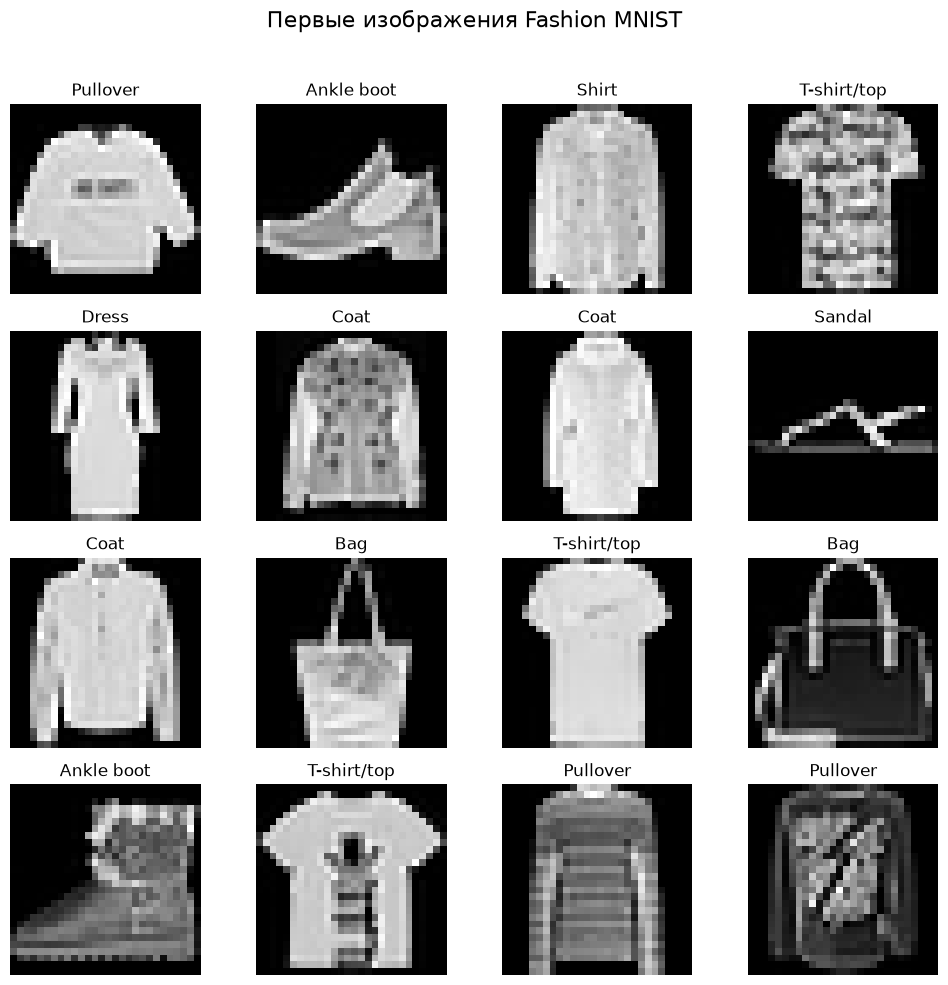

In [33]:
def show_sample_images(features, labels, n=16, title="Первые изображения Fashion MNIST"):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.asarray(features[i]).reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray")
        ax.set_title(CLASS_NAMES[int(labels[i])])
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


set_seed(SEED)
ROOT = find_project_root()
DATA_DIR = ROOT / "data"
DEVICE = configure_runtime()
print(f"Device: {DEVICE}")
print(f"CPU threads: {torch.get_num_threads()}")
print(f"Data dir: {DATA_DIR}")

train_features, train_labels = load_csv_xy(DATA_DIR / "fashion-mnist_train.csv")
test_features, test_labels = load_csv_xy(DATA_DIR / "fashion-mnist_test.csv")
print("Train:", train_features.shape, "Test:", test_features.shape)
show_sample_images(train_features, train_labels)


In [34]:
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = create_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    val_size=VAL_SIZE,
    num_workers=NUM_WORKERS,
)
images, labels = next(iter(train_loader))
print("Батч:", tuple(images.shape), tuple(labels.shape))
print("Train / val / test:", len(train_dataset), len(val_dataset), len(test_dataset))


Батч: (96, 1, 28, 28) (96,)
Train / val / test: 54000 6000 10000


## 6. Функция потерь, AdamW и обучение

In [35]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1.0 - pt) ** self.gamma * ce_loss).mean()


def make_criterion():
    if USE_FOCAL_LOSS:
        return FocalLoss()
    return nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def make_optimizer(model: nn.Module):
    return torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=ADAM_BETAS,
        weight_decay=WEIGHT_DECAY,
    )


def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(NUM_EPOCHS, 1), eta_min=ETA_MIN
    )


def maybe_tensorboard_writer(log_dir: Path):
    try:
        from torch.utils.tensorboard import SummaryWriter
        return SummaryWriter(log_dir=str(log_dir))
    except Exception:
        print("TensorBoard недоступен, кривые обучения будут построены через matplotlib.")
        return None


In [36]:
@torch.no_grad()
def run_eval_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(inputs)
        running_loss += criterion(outputs, labels).item() * inputs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, writer=None, scheduler=None):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = run_eval_epoch(model, val_loader, criterion, device)
        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if writer is not None:
            writer.add_scalar("Loss/train", train_loss, epoch + 1)
            writer.add_scalar("Loss/val", val_loss, epoch + 1)
            writer.add_scalar("Accuracy/train", train_acc, epoch + 1)
            writer.add_scalar("Accuracy/val", val_acc, epoch + 1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


In [37]:
model = ResNet18(num_classes=NUM_CLASSES, in_channels=1).to(DEVICE)
criterion = make_criterion()
optimizer = make_optimizer(model)
scheduler = make_scheduler(optimizer)
writer = maybe_tensorboard_writer(ROOT / "runs" / "fashion_mnist_resnet18")

print(optimizer)
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    DEVICE,
    num_epochs=NUM_EPOCHS,
    writer=writer,
    scheduler=scheduler,
)
torch.save(model.state_dict(), ROOT / "src" / "fashion_mnist_resnet18.pth")
print("Модель сохранена.")


TensorBoard недоступен, кривые обучения будут построены через matplotlib.
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0003
    lr: 0.0003
    maximize: False
    weight_decay: 0.0001
)
Epoch 1/12 - train_loss: 0.9185, train_acc: 0.8115, val_loss: 0.7653, val_acc: 0.8803
Epoch 2/12 - train_loss: 0.7698, train_acc: 0.8777, val_loss: 0.7349, val_acc: 0.8930
Epoch 3/12 - train_loss: 0.7290, train_acc: 0.8963, val_loss: 0.7296, val_acc: 0.8970
Epoch 4/12 - train_loss: 0.7087, train_acc: 0.9056, val_loss: 0.6714, val_acc: 0.9217
Epoch 5/12 - train_loss: 0.6880, train_acc: 0.9158, val_loss: 0.6786, val_acc: 0.9192
Epoch 6/12 - train_loss: 0.6710, train_acc: 0.9226, val_loss: 0.6634, val_acc: 0.9247
Epoch 7/12 - train_loss: 0.6579, train_acc: 0.9286, val_loss: 0.6542, val_acc: 0.9318
Epoch 8/12 - train_loss: 0.6446, train_a

## 7. Оценка на тесте


In [38]:
@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for inputs, labels in dataloader:
        outputs = model(inputs.to(device, non_blocking=True))
        probs = torch.softmax(outputs, dim=1)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)
    metrics = {
        "accuracy": (y_true == y_pred).mean(),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "roc_auc": roc_auc_score(y_true, y_prob, average="weighted", multi_class="ovr"),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
    print("Confusion Matrix:")
    print(metrics["confusion_matrix"])
    return metrics


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_title("Confusion Matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=8)
    plt.tight_layout()
    plt.show()


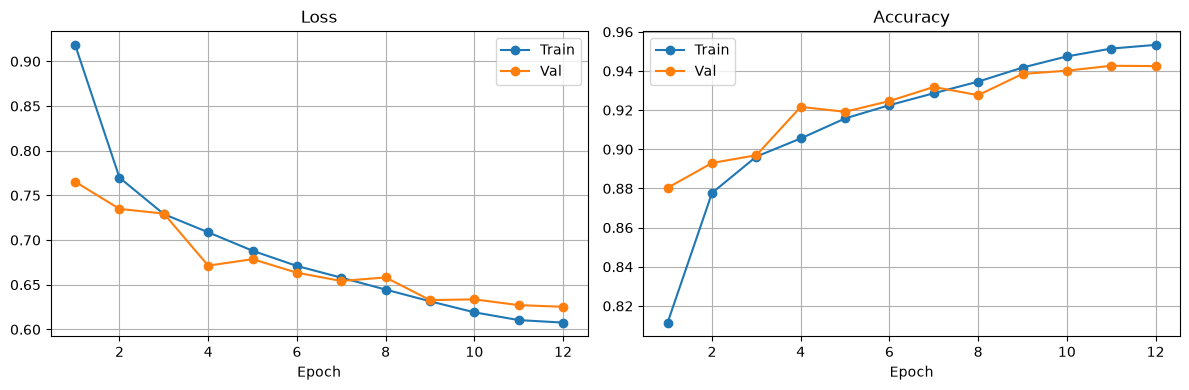

Accuracy: 0.9496
F1 Score: 0.9496
ROC-AUC: 0.9970
Confusion Matrix:
[[909   0  14   5   1   0  70   0   1   0]
 [  0 996   0   3   1   0   0   0   0   0]
 [ 10   0 935  12  21   0  22   0   0   0]
 [ 13   5   4 954   9   0  13   0   2   0]
 [  0   0  15  16 930   0  39   0   0   0]
 [  0   0   0   0   0 979   0  10   1  10]
 [ 72   3  29  17  30   0 848   0   1   0]
 [  0   0   0   0   0   6   0 967   0  27]
 [  0   1   0   0   2   1   1   0 995   0]
 [  0   0   0   1   0   0   0  16   0 983]]


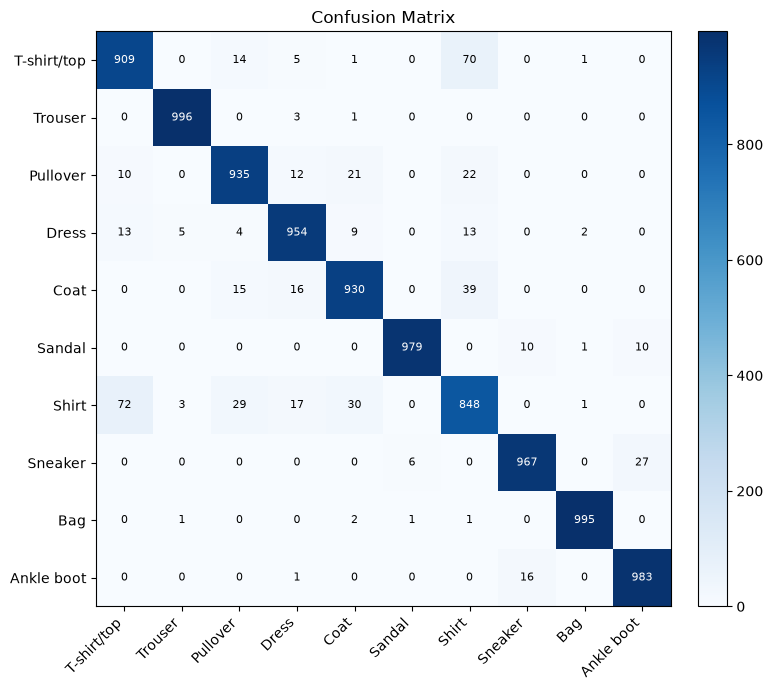

In [39]:
plot_history(history)
metrics = evaluate_model(model, test_loader, DEVICE)
plot_confusion_matrix(metrics["confusion_matrix"])


## 8. Предсказания и Grad-CAM


In [40]:
def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().numpy()
    if image.ndim == 3:
        image = image[0]
    return np.clip(image * FASHION_STD + FASHION_MEAN, 0.0, 1.0)


def visualize_prediction(model, dataset, index, device):
    model.eval()
    image, label = dataset[index]
    with torch.no_grad():
        predicted = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    plt.figure(figsize=(4, 4))
    plt.imshow(denormalize(image), cmap="gray")
    plt.title(f"True: {CLASS_NAMES[label]} | Pred: {CLASS_NAMES[predicted]}")
    plt.axis("off")
    plt.show()
    return predicted


def show_prediction_grid(model, dataset, device, n=16):
    model.eval()
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle("Случайные предсказания на тесте", fontsize=14)
    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            image, label = dataset[idx]
            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
            ax.imshow(denormalize(image), cmap="gray")
            ax.set_title(CLASS_NAMES[pred], color="green" if pred == label else "red", fontsize=9)
            ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [41]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        x = image_tensor.unsqueeze(0)
        x.requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        self.model.zero_grad(set_to_none=True)
        logits[0, class_idx].backward()
        weights = self.gradients[0].mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * self.activations[0]).sum(0))
        cam = (cam / (cam.max() + 1e-8)).cpu().numpy()
        cam = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
        return cam, class_idx, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def visualize_gradcam(model, dataset, index, device):
    image, label = dataset[index]
    image = image.to(device)
    cam_extractor = GradCAM(model, model.layer4[-1])
    heatmap, predicted, _ = cam_extractor.generate(image)
    cam_extractor.close()

    gray = (denormalize(image) * 255).astype(np.uint8)
    overlay_base = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    heatmap_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.cvtColor(cv2.addWeighted(overlay_base, 0.55, heatmap_color, 0.45, 0), cv2.COLOR_BGR2RGB)
    edges = cv2.Canny(gray, 50, 150)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(f"Input\n{CLASS_NAMES[label]}")
    axes[1].imshow(255 - edges, cmap="gray")
    axes[1].imshow(heatmap, cmap="coolwarm", alpha=0.55)
    axes[1].set_title("Grad-CAM + edges")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPred: {CLASS_NAMES[predicted]}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return predicted


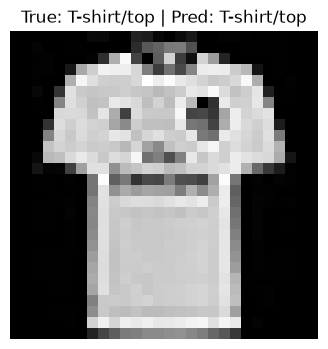

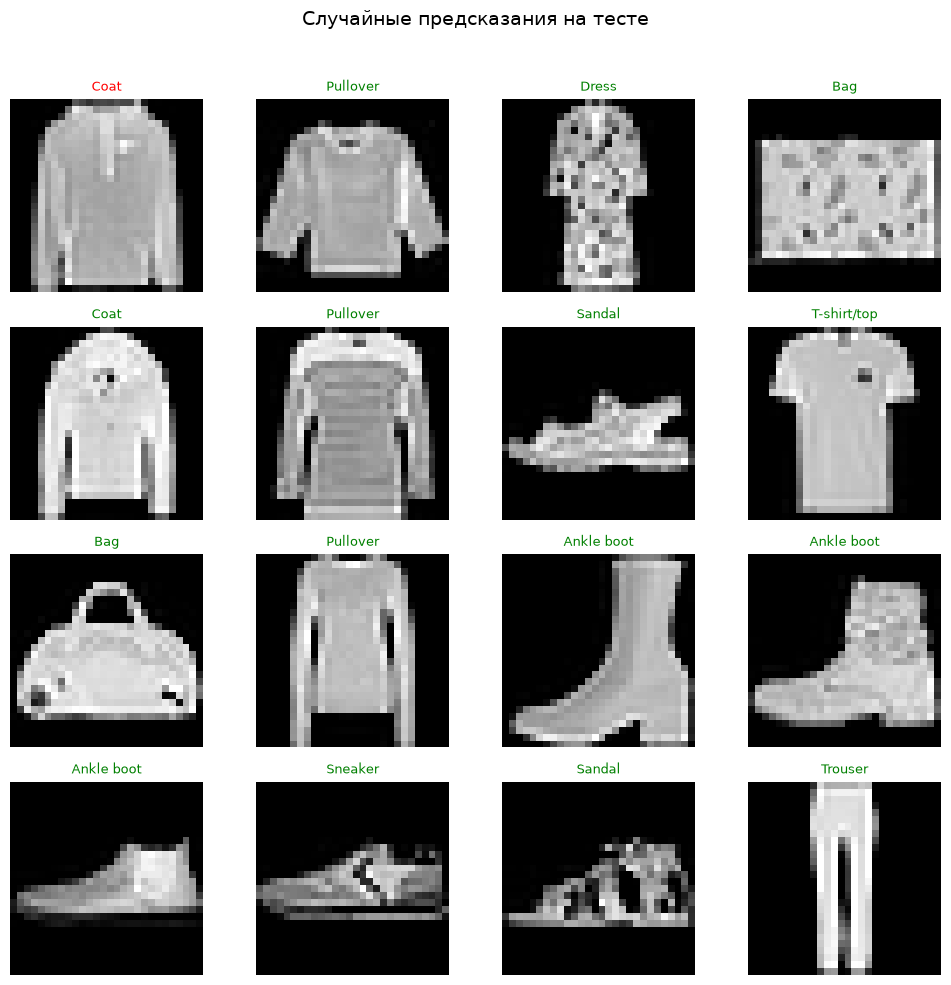

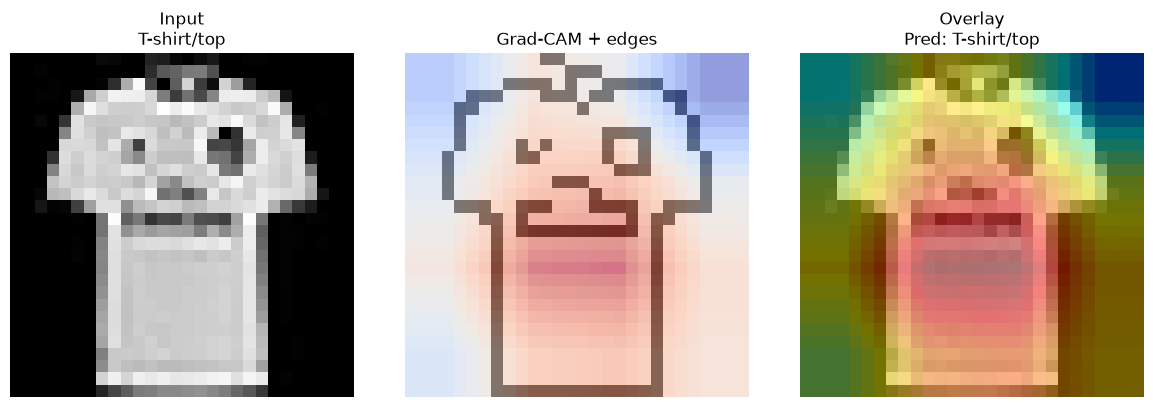

In [53]:
def load_and_preprocess_image(image_path: Path, transform=None):
    image = Image.open(image_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    image_np = np.array(image, dtype=np.uint8)
    if transform is None:
        transform = get_eval_transforms()
    return transform(image=image_np)["image"].unsqueeze(0)


def test_on_real_data(model, image_paths, device):
    model.eval()
    transform = get_eval_transforms()
    predictions = []
    with torch.no_grad():
        for path in image_paths:
            predicted_class = model(load_and_preprocess_image(path, transform).to(device)).argmax(dim=1).item()
            predictions.append((str(path), CLASS_NAMES[predicted_class]))
            print(f"Image {path}: Predicted Class {CLASS_NAMES[predicted_class]}")
    return predictions


visualize_prediction(model, test_dataset, index=0, device=DEVICE)
show_prediction_grid(model, test_dataset, DEVICE)
visualize_gradcam(model, test_dataset, index=0, device=DEVICE)


if writer is not None:
    writer.close()